<a href="https://www.kaggle.com/code/sonawanelalitsunil/dating-app-user-behavior-dataset-ml-10-4?scriptVersionId=232117276" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dating-app-behavior-dataset/dating_app_behavior_dataset.csv


## Title: Dating App User Behavior Dataset

#### Description: A dataset capturing user interactions, preferences, and engagement patterns on a dating app, useful for behavioral analysis and recommendation systems.

In [2]:
df = pd.read_csv('/kaggle/input/dating-app-behavior-dataset/dating_app_behavior_dataset.csv')

In [3]:
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [4]:
df.tail()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
49995,Transgender,Gay,Metro,Very High,Postdoc,"Gaming, Writing, Painting",130,Addicted,0.69,Optimistic,99,8,5,235,9,0.19,15,Afternoon,Ghosted
49996,Female,Lesbian,Small Town,Low,Diploma,"Traveling, Fitness, Stand-up Comedy",277,Extreme User,0.43,Optimistic,173,1,1,278,69,0.23,2,Evening,Ghosted
49997,Male,Bisexual,Remote Area,High,High School,"Gaming, Motorcycling, Art",73,High,0.50,Optimistic,123,8,1,128,94,0.36,5,After Midnight,Blocked
49998,Transgender,Queer,Urban,Low,MBA,"Skating, Astrology, Hiking",100,High,0.34,Balanced,149,19,3,206,53,0.36,16,Evening,One-sided Like
49999,Prefer Not to Say,Pansexual,Metro,Lower-Middle,Bachelor’s,"Crafting, Spirituality, Coding",119,High,0.56,Optimistic,114,17,0,395,68,0.50,16,Early Morning,No Action


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

In [6]:
df.describe()

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


In [7]:
df.shape

(50000, 19)

In [8]:
df.dtypes

gender                   object
sexual_orientation       object
location_type            object
income_bracket           object
education_level          object
interest_tags            object
app_usage_time_min        int64
app_usage_time_label     object
swipe_right_ratio       float64
swipe_right_label        object
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day        object
match_outcome            object
dtype: object

In [9]:
df.isnull().sum()

gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length              0
message_sent_count      0
emoji_usage_rate        0
last_active_hour        0
swipe_time_of_day       0
match_outcome           0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['gender', 'sexual_orientation', 'location_type', 'income_bracket',
       'education_level', 'interest_tags', 'app_usage_time_min',
       'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label',
       'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length',
       'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
       'swipe_time_of_day', 'match_outcome'],
      dtype='object')

## Data visualizations

In [12]:
# Set aesthetic style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

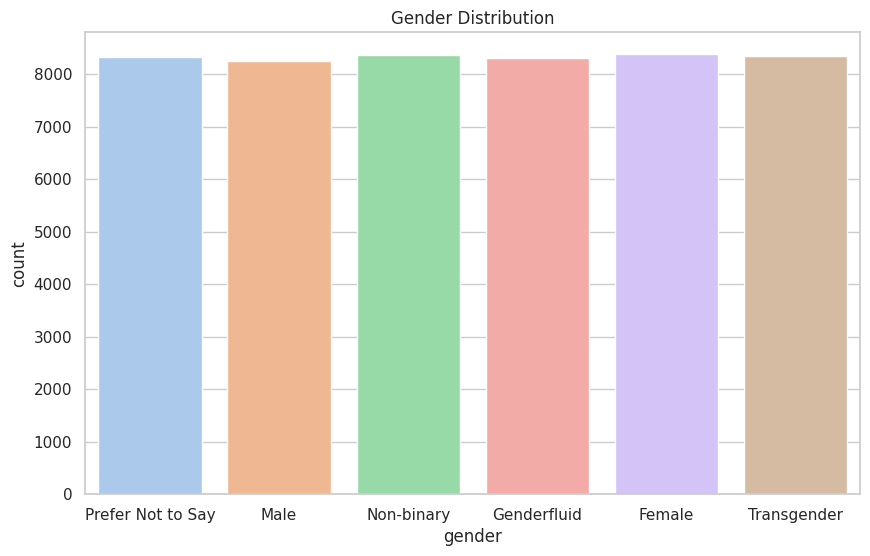

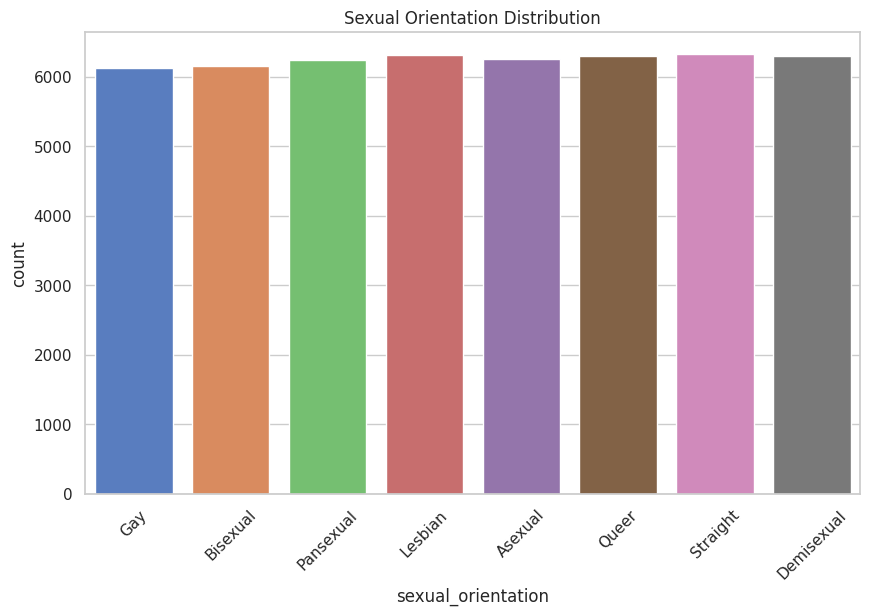

In [13]:
# Gender
sns.countplot(data=df, x='gender', palette='pastel')
plt.title("Gender Distribution")
plt.show()

# Sexual Orientation
sns.countplot(data=df, x='sexual_orientation', palette='muted')
plt.title("Sexual Orientation Distribution")
plt.xticks(rotation=45)
plt.show()


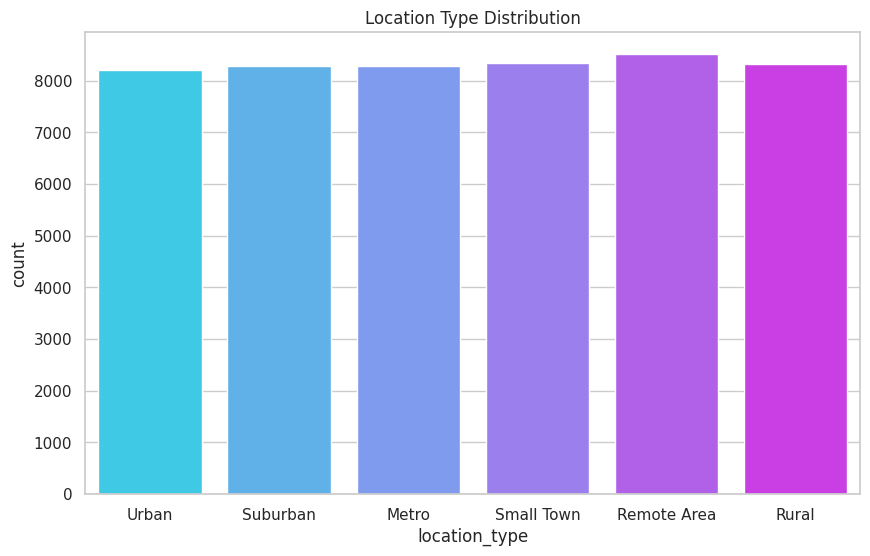

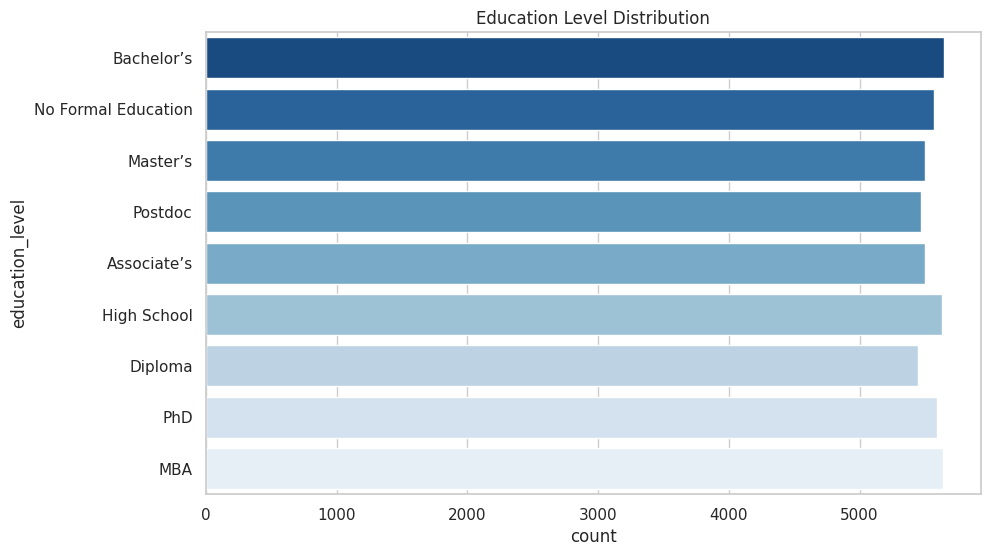

In [14]:
sns.countplot(data=df, x='location_type', palette='cool')
plt.title("Location Type Distribution")
plt.show()

sns.countplot(data=df, y='education_level', palette='Blues_r')
plt.title("Education Level Distribution")
plt.show()


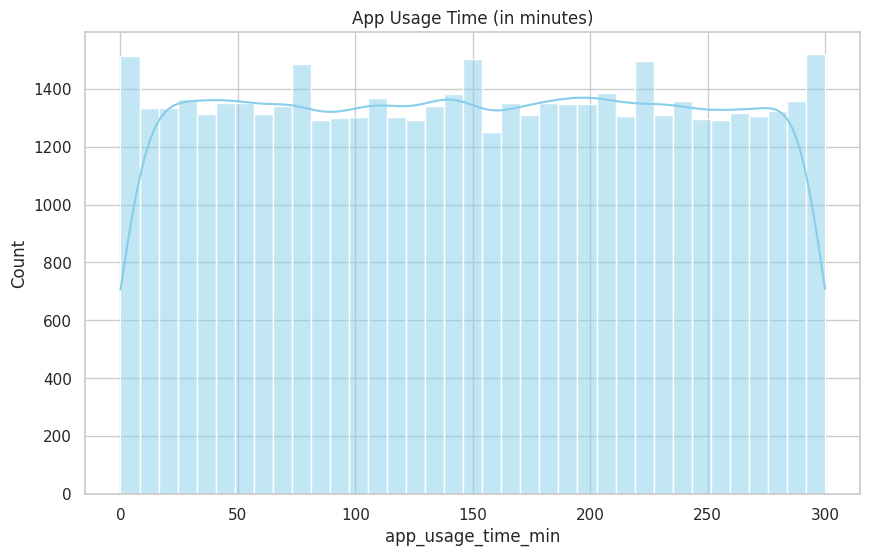

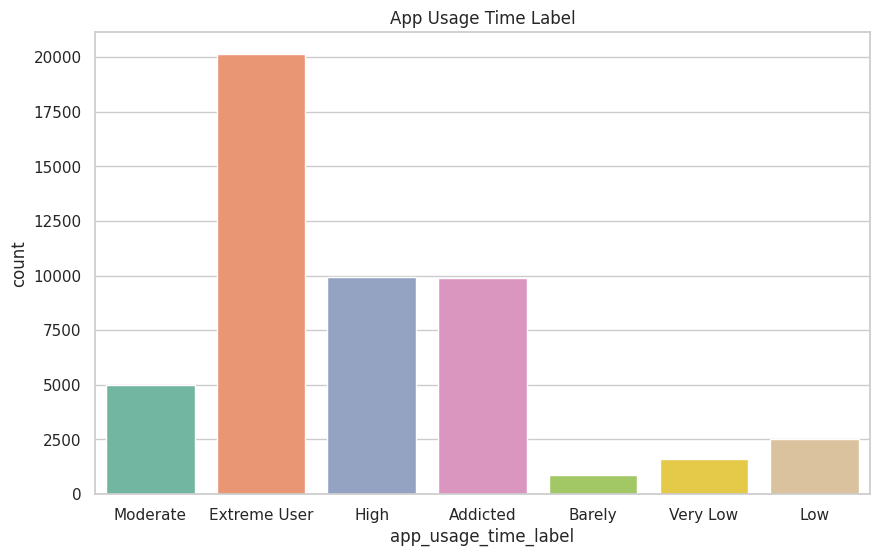

In [15]:
# Continuous usage
sns.histplot(df['app_usage_time_min'], kde=True, color='skyblue')
plt.title("App Usage Time (in minutes)")
plt.show()

# Label-based usage
sns.countplot(data=df, x='app_usage_time_label', palette='Set2')
plt.title("App Usage Time Label")
plt.show()


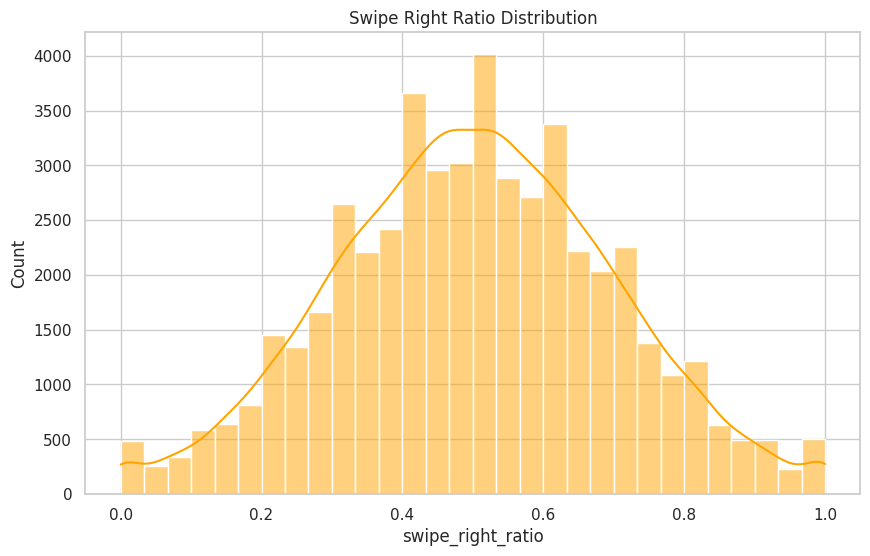

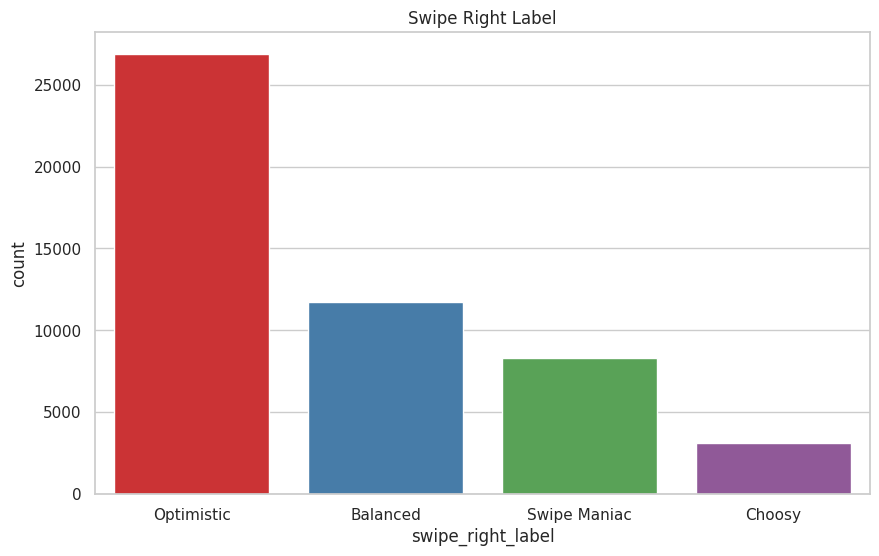

In [16]:
sns.histplot(df['swipe_right_ratio'], bins=30, kde=True, color='orange')
plt.title("Swipe Right Ratio Distribution")
plt.show()

sns.countplot(data=df, x='swipe_right_label', palette='Set1')
plt.title("Swipe Right Label")
plt.show()


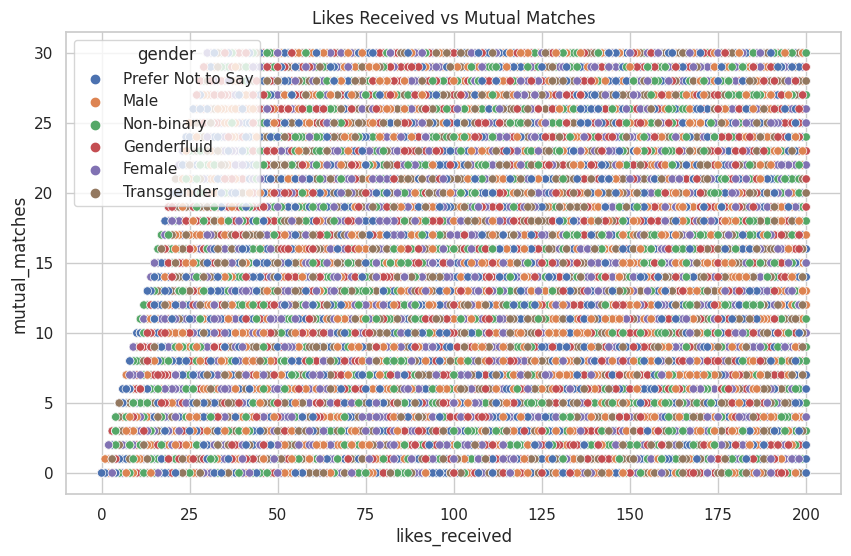

In [17]:
sns.scatterplot(data=df, x='likes_received', y='mutual_matches', hue='gender')
plt.title("Likes Received vs Mutual Matches")
plt.show()


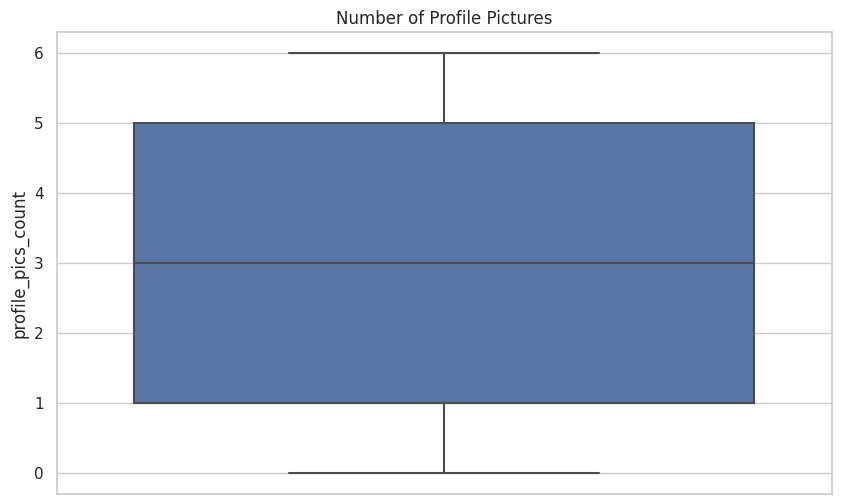

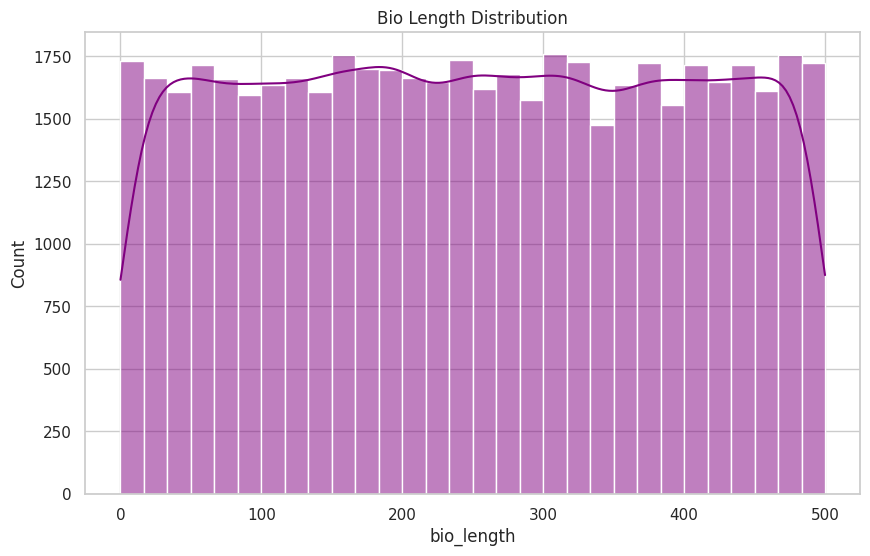

In [18]:
sns.boxplot(data=df, y='profile_pics_count')
plt.title("Number of Profile Pictures")
plt.show()

sns.histplot(df['bio_length'], bins=30, kde=True, color='purple')
plt.title("Bio Length Distribution")
plt.show()


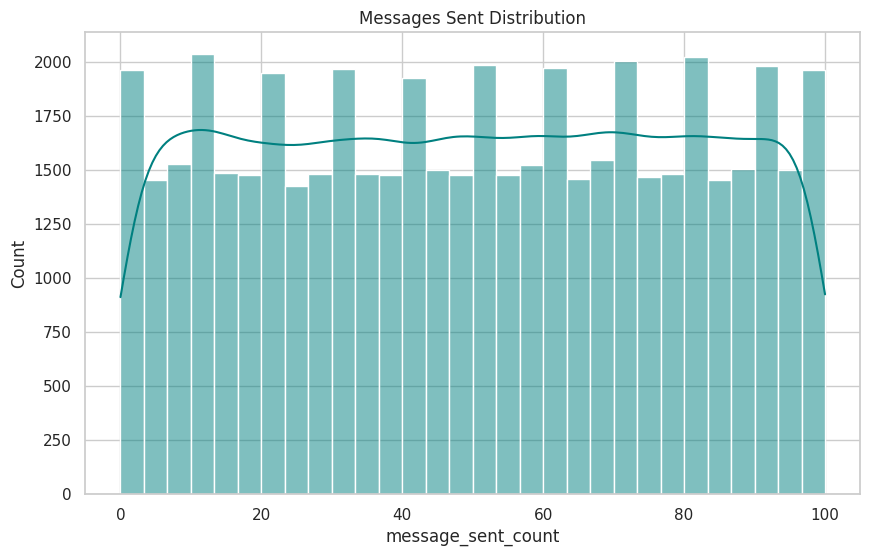

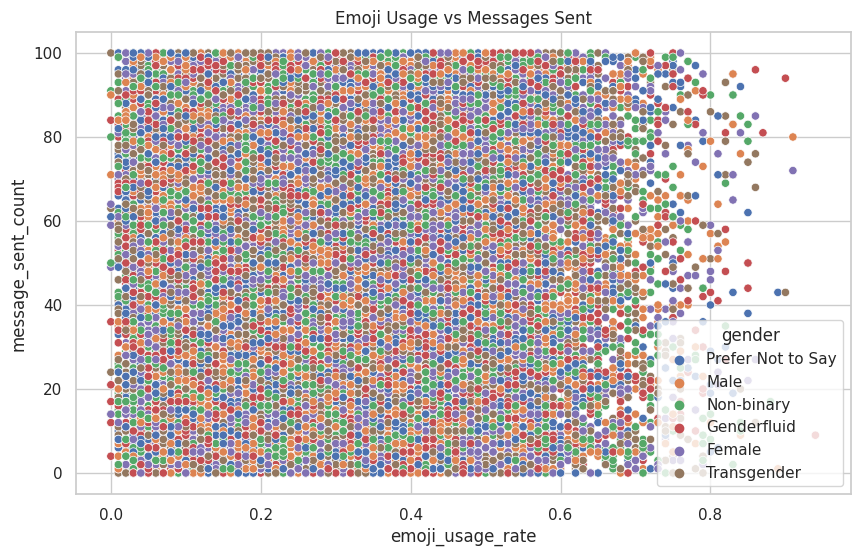

In [19]:
sns.histplot(df['message_sent_count'], bins=30, kde=True, color='teal')
plt.title("Messages Sent Distribution")
plt.show()

sns.scatterplot(data=df, x='emoji_usage_rate', y='message_sent_count', hue='gender')
plt.title("Emoji Usage vs Messages Sent")
plt.show()


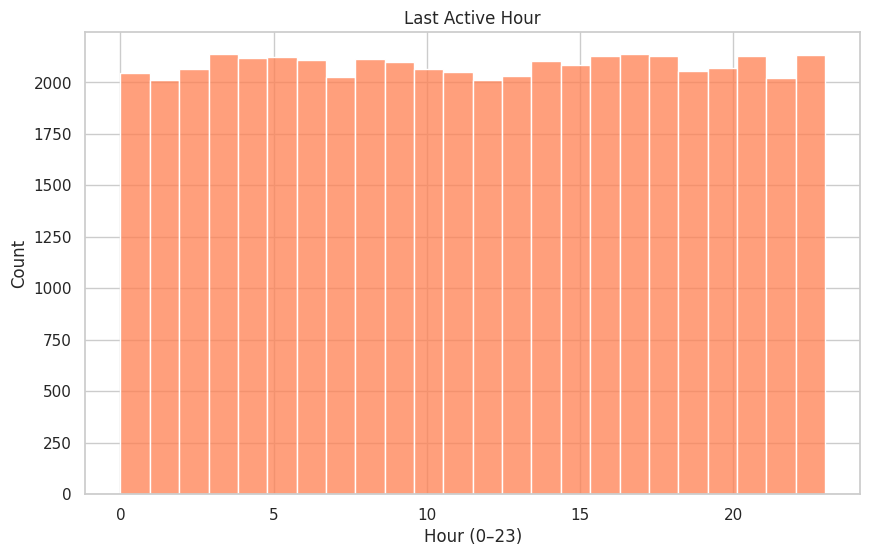

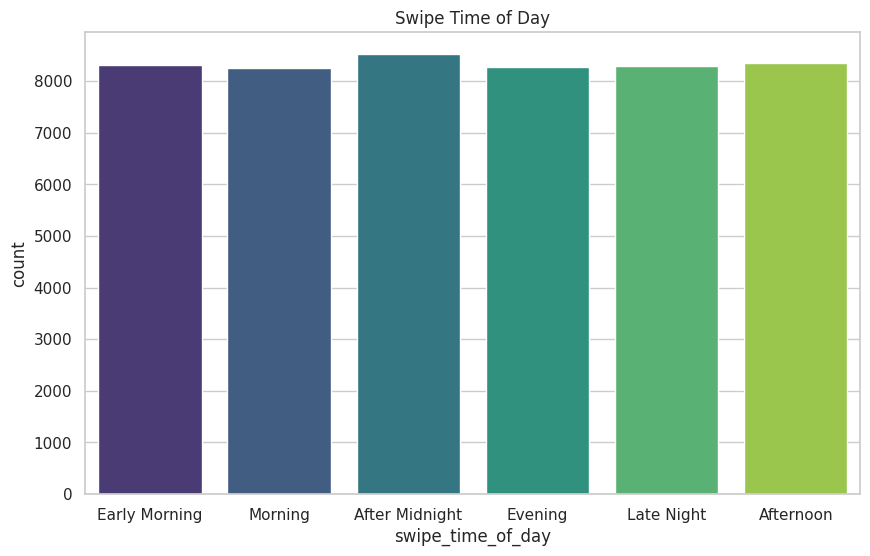

In [20]:
sns.histplot(df['last_active_hour'], bins=24, color='coral')
plt.title("Last Active Hour")
plt.xlabel("Hour (0–23)")
plt.show()

sns.countplot(data=df, x='swipe_time_of_day', palette='viridis')
plt.title("Swipe Time of Day")
plt.show()


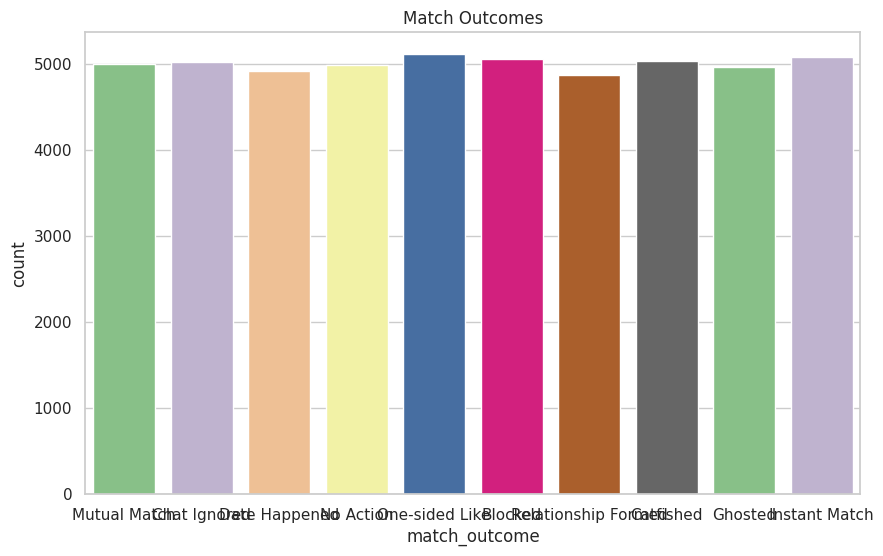

In [21]:
sns.countplot(data=df, x='match_outcome', palette='Accent')
plt.title("Match Outcomes")
plt.show()


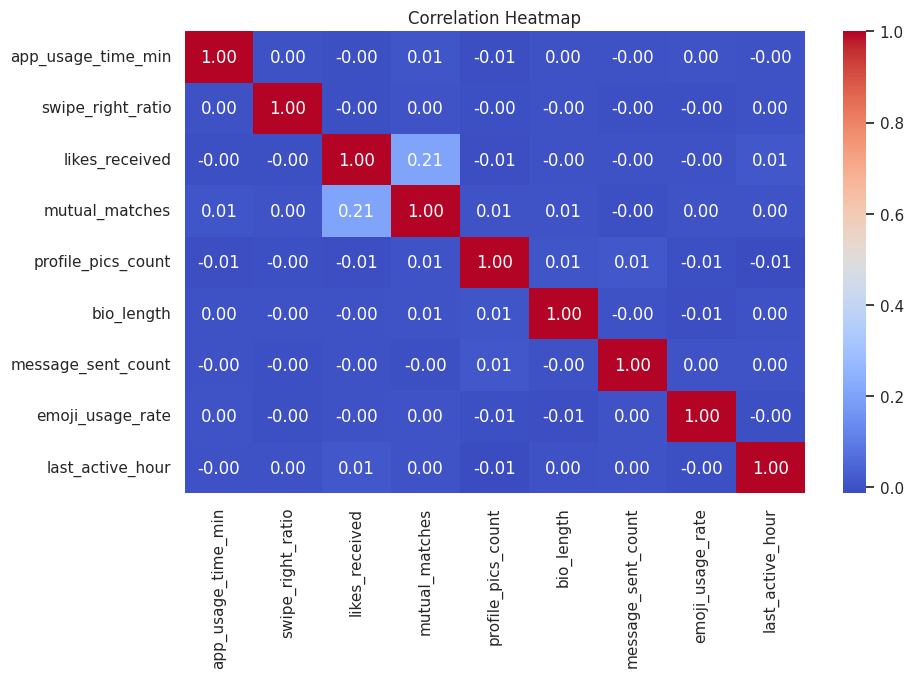

In [22]:
# Select numerical columns
num_cols = df.select_dtypes(include='number')

# Compute correlations
corr = num_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [25]:
# Target variable
target = 'match_outcome'

# Encode categorical variables
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [26]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc * 100  # Save as percentage
    
    print(f"\n🔍 {name}")
    print(f"Accuracy: {acc * 100:.2f}%")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')



🔍 Logistic Regression
Accuracy: 9.85%

🔍 Decision Tree
Accuracy: 9.87%

🔍 Random Forest
Accuracy: 9.78%

🔍 Support Vector Machine
Accuracy: 9.92%

🔍 Naive Bayes
Accuracy: 9.70%

🔍 K-Nearest Neighbors
Accuracy: 9.92%


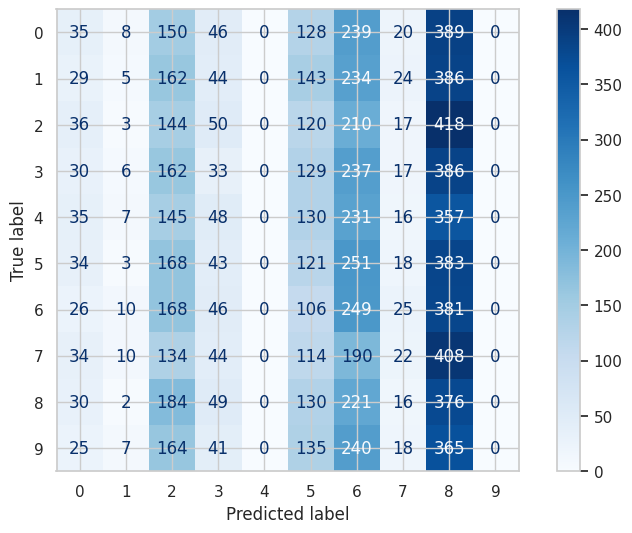

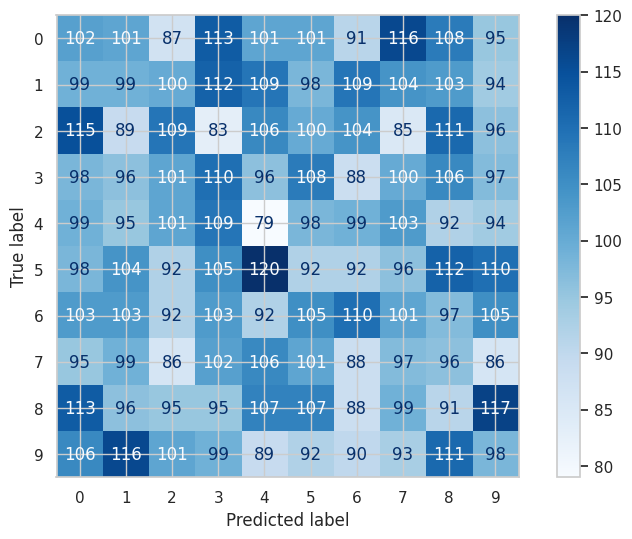

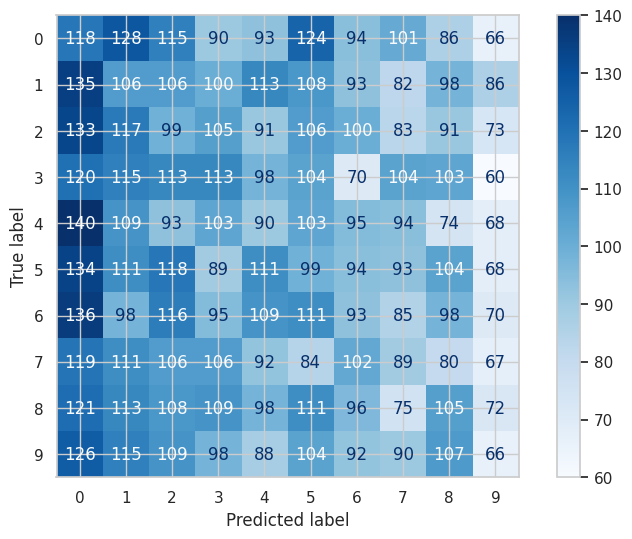

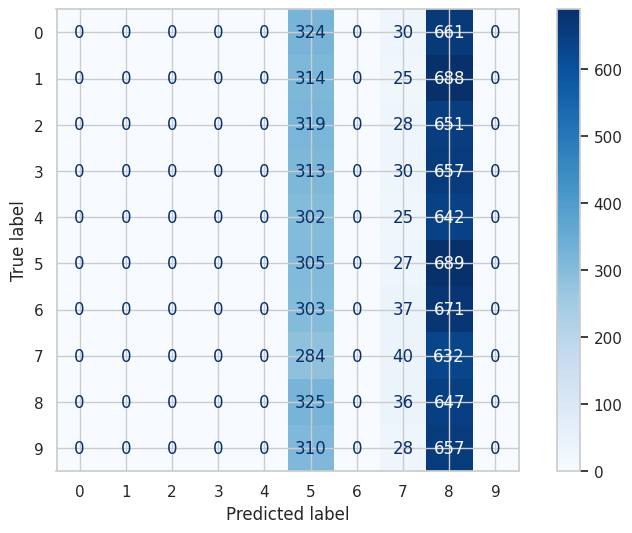

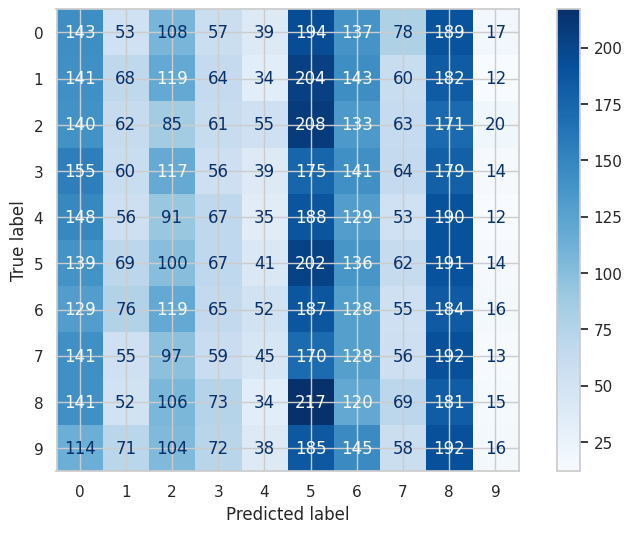

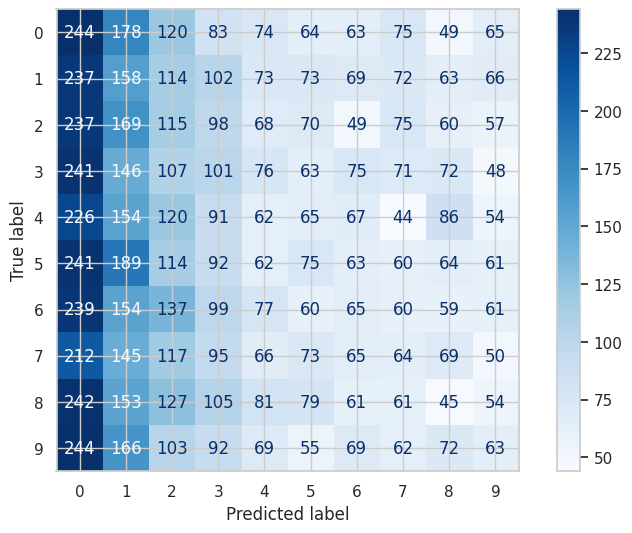

In [28]:
for name, model in models.items():
    evaluate_model(name, model)


In [29]:
# Display all results sorted
acc_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (%)'])
acc_df = acc_df.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)
print("\n📊 Accuracy Summary")
print(acc_df)



📊 Accuracy Summary
                    Model  Accuracy (%)
0  Support Vector Machine          9.92
1     K-Nearest Neighbors          9.92
2           Decision Tree          9.87
3     Logistic Regression          9.85
4           Random Forest          9.78
5             Naive Bayes          9.70


## Thank you..pls upvote!!!